# Data Preprocessing
**Mục tiêu**: Kiểm tra ma trận tương quan giữa các biến đầu vào và biến mục tiêu `NDVI_Season_Mean` để chuẩn bị cho quá trình huấn luyện mô hình.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [128]:
# Tải dữ liệu
df = pd.read_csv('../Data Collection/Bangladesh_database_Final_Merged.csv')
df.head()

,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Avg Humidity,Heat_Stress_Days,Silt,Growth,CN_Ratio,Crop Name,Organic_Carbon,Transplant,Season,NDVI_Season_Mean
0,6.314995,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,55.0,0,49.52,Jan to March,8.73,Wheat,33.97,Dec,Rabi,0.511809
1,6.314995,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,60.0,0,49.52,Jan to March,8.73,Maize 2,33.97,Dec,Rabi,0.511809
2,6.314995,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,72.5,0,49.52,Dec to March,8.73,Boro,33.97,Nov,Rabi,0.511809
3,6.314995,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,80.0,0,49.52,Dec to March,8.73,Sweet Potato,33.97,Nov,Rabi,0.511809
4,4.169442,883.021928,0.308177,22.73,656.33,2.481885,16.01,5.86,41.26,Bagerhat,...,70.0,54,49.52,No need to do,8.73,Mango,33.97,April,Kharif 1,0.267147


## 1. Tính toán ma trận tương quan
Chúng ta sẽ lọc ra các biến dạng số (numeric) để tính ma trận tương quan Pearson.

In [129]:
# Lọc các cột dạng số (numeric)
numeric_df = df.select_dtypes(include=[np.number])

# Tính ma trận tương quan Pearson
corr_matrix = numeric_df.corr()

# Lấy ra mức độ tương quan của các biến với biến mục tiêu NDVI_Season_Mean
corr_with_target = corr_matrix['NDVI_Season_Mean'].sort_values(ascending=False)

print("Tương quan với NDVI_Season_Mean:")
print(corr_with_target)

Tương quan với NDVI_Season_Mean:
NDVI_Season_Mean      1.000000
FPAR                  0.846879
EVI                   0.604625
LAI                   0.570205
Silt                  0.167114
pH                    0.105432
Nitrogen              0.022350
Organic_Carbon        0.011538
CN_Ratio              0.011236
Clay                 -0.005471
Soil_Moisture_mm     -0.067330
Temp_Min             -0.138870
Avg Humidity         -0.139257
Wind_Max             -0.149853
Rain_Temp_Ratio      -0.345980
LST_Kelvin           -0.350658
Rainfall             -0.352983
Temp_Mean            -0.365827
Wind_Mean            -0.395441
Heat_Stress_Days     -0.451259
Temp_Max             -0.468861
Avg_Salinity_Index   -0.790492
Name: NDVI_Season_Mean, dtype: float64


## 2. Trực quan hóa bằng Heatmap
Heatmap giúp chúng ta nhìn nhận rõ ràng hơn sự tương quan giữa TẤT CẢ các cặp biến.

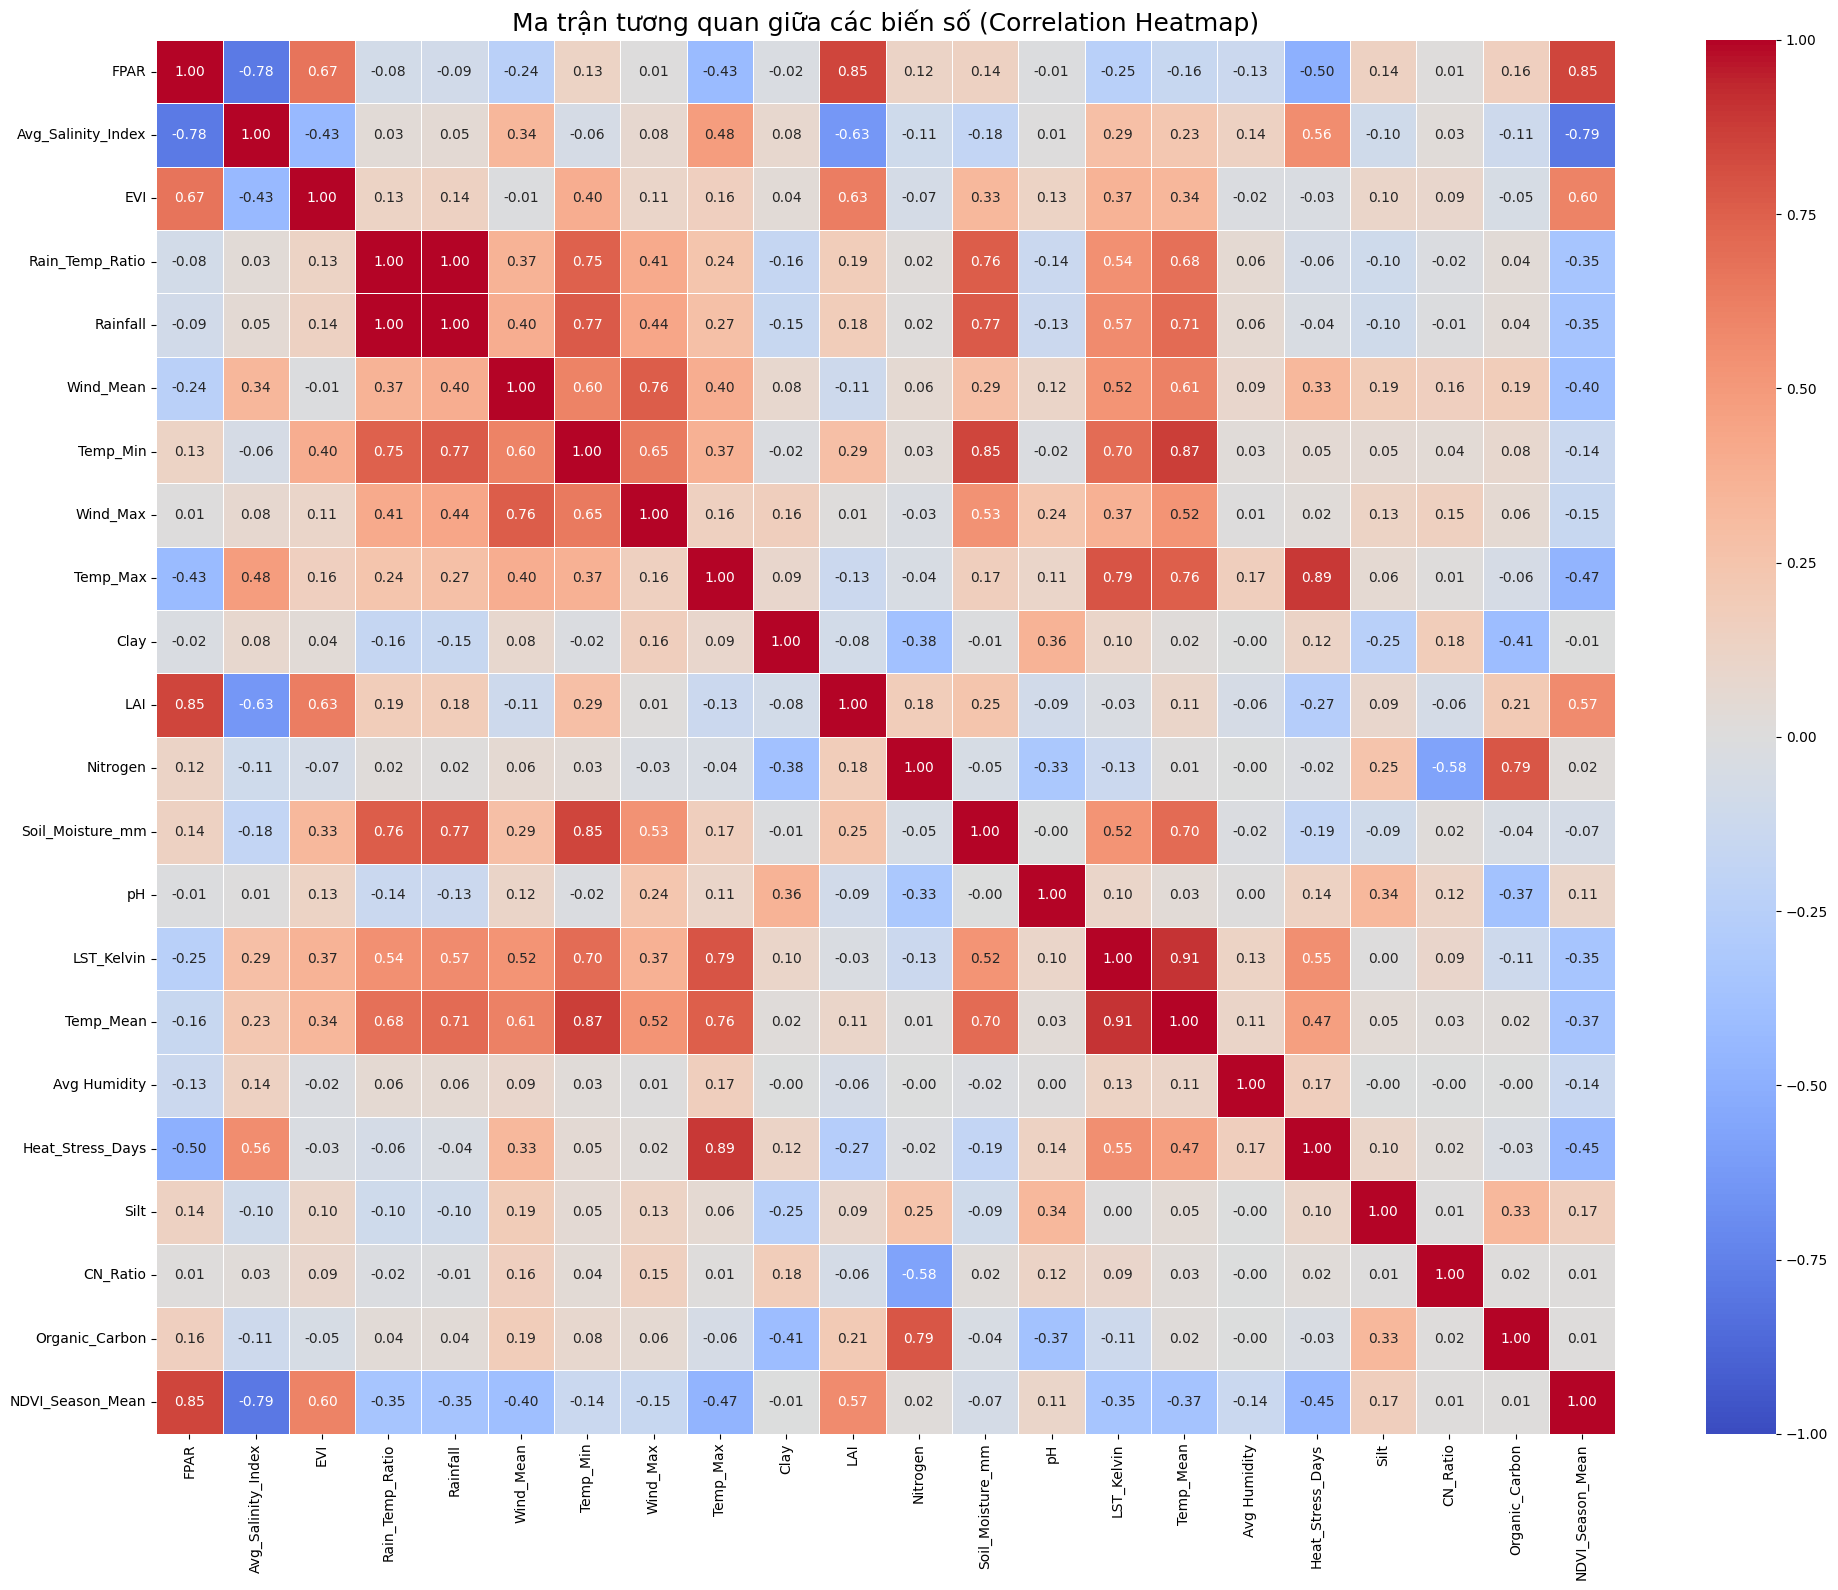

In [130]:
plt.figure(figsize=(20, 16))
# Vẽ heatmap cho ma trận tương quan
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số (Correlation Heatmap)', fontsize=18)
plt.tight_layout()
plt.show()

## Từ biểu đồ trên chúng ta thấy:

Rain_Temp_Ratio & Rainfall (0.999) 

LST_Kelvin & Temp_Mean (0.906)

Heat_Stress_Days & Temp_Max (0.891)

Temp_Mean & Temp_Min (0.874)

FPAR & LAI (0.849)

Soil_Moisture_mm & Temp_Min (0.847)

Cần đánh giá giá xem biến nào sẽ nên xóa đi và nên ở lại 

## Phân tích sâu cặp biến Rainfall và Rain_Temp_Ratio (Tương quan 0.999)
Mức độ tương quan 0.999 có nghĩa là hai biến này gần như là một đường thẳng hoàn hảo. Để quyết định nên giữ biến nào và xóa biến nào, chúng ta sẽ thực hiện các bước sau:
1. Vẽ biểu đồ phân tán (Scatter Plot) giữa 2 biến.
2. So sánh hình dáng phân phối của chúng đối với biến mục tiêu `NDVI_Season_Mean`.
3. Đưa ra lập luận toán học và quyết định.

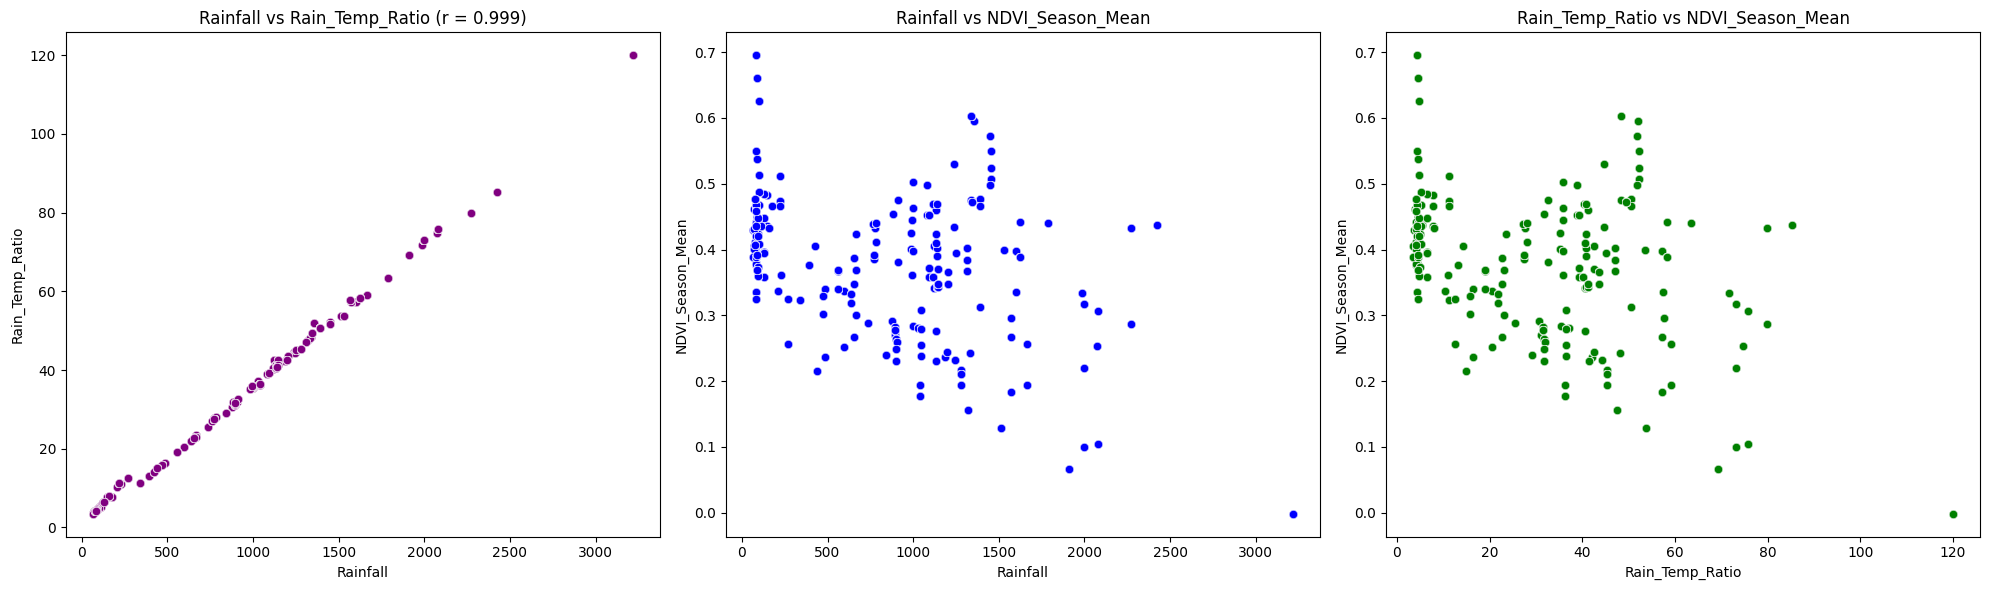

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Mối quan hệ giữa Rainfall và Rain_Temp_Ratio
sns.scatterplot(data=df, x='Rainfall', y='Rain_Temp_Ratio', ax=axes[0], color='purple', alpha=0.6)
axes[0].set_title('Rainfall vs Rain_Temp_Ratio (r = 0.999)')

# 2. Mối quan hệ giữa Rainfall và Target
sns.scatterplot(data=df, x='Rainfall', y='NDVI_Season_Mean', ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('Rainfall vs NDVI_Season_Mean')

# 3. Mối quan hệ giữa Rain_Temp_Ratio và Target
sns.scatterplot(data=df, x='Rain_Temp_Ratio', y='NDVI_Season_Mean', ax=axes[2], color='green', alpha=0.6)
axes[2].set_title('Rain_Temp_Ratio vs NDVI_Season_Mean')

plt.tight_layout()
plt.show()

## Dùng OLS để quyết định Drop
Cách chứng minh mạnh mẽ nhất là thực hiện phép thử nghiệm trực tiếp trên mô hình học máy (A/B Testing). Chúng ta sẽ dùng thuật toán **Hồi quy Tuyến tính (OLS - Ordinary Least Squares)** để kiểm định ý nghĩa thống kê (P-value), độ phân giải (R-squared) và sự ổn định của trọng số.

In [132]:
import statsmodels.api as sm

# Chuẩn bị tập dữ liệu nhỏ gọn (Lọc bỏ NaN nếu có)
test_df = df[['Rainfall', 'Rain_Temp_Ratio', 'NDVI_Season_Mean']].dropna()
y_test = test_df['NDVI_Season_Mean']

def run_ols(features, name):
    X_test = test_df[features]
    X_test = sm.add_constant(X_test) # Thêm hệ số chặn (Intercept)
    model = sm.OLS(y_test, X_test).fit()
    print(f"\n{'='*60}")
    print(f"KỊCH BẢN: {name}")
    print(f"R-squared: {model.rsquared:.5f}")
    print(f"\nTrọng số:\n{model.params[1:]}")
    print(f"\nP-values:\n{model.pvalues[1:]}")
    print(f"{'='*60}")
    return model

In [133]:
# Kịch bản 1: Dùng cả 2 biến (Chứng minh rủi ro phá hoại mô hình)
run_ols(['Rainfall', 'Rain_Temp_Ratio'], "DÙNG CẢ 2 BIẾN CÙNG LÚC")

# Kịch bản 2: Dùng mô hình chỉ có Rainfall
run_ols(['Rainfall'], "CHỈ DÙNG RAINFALL")

# Kịch bản 3: Dùng mô hình chỉ có Rain_Temp_Ratio
run_ols(['Rain_Temp_Ratio'], "CHỈ DÙNG RAIN_TEMP_RATIO")
print("")


KỊCH BẢN: DÙNG CẢ 2 BIẾN CÙNG LÚC
R-squared: 0.14323

Trọng số:
Rainfall          -0.000553
Rain_Temp_Ratio    0.013928
dtype: float64

P-values:
Rainfall           5.853486e-29
Rain_Temp_Ratio    2.464267e-23
dtype: float64

KỊCH BẢN: CHỈ DÙNG RAINFALL
R-squared: 0.12460

Trọng số:
Rainfall   -0.000061
dtype: float64

P-values:
Rainfall    2.674356e-135
dtype: float64

KỊCH BẢN: CHỈ DÙNG RAIN_TEMP_RATIO
R-squared: 0.11970

Trọng số:
Rain_Temp_Ratio   -0.001705
dtype: float64

P-values:
Rain_Temp_Ratio    1.029896e-129
dtype: float64



In [134]:
if 'Rain_Temp_Ratio' in df.columns:
    df.drop(columns=['Rain_Temp_Ratio'], inplace=True)
    print("Đã xóa thành công cột 'Rain_Temp_Ratio'.")
else:
    print("Cột 'Rain_Temp_Ratio' đã được xóa từ trước.")
print("\nSố lượng cột còn lại:", len(df.columns))
print("\nDanh sách cột hiện tại:")
print(df.columns.tolist())

Đã xóa thành công cột 'Rain_Temp_Ratio'.

Số lượng cột còn lại: 28

Danh sách cột hiện tại:
['FPAR', 'Avg_Salinity_Index', 'EVI', 'Rainfall', 'Wind_Mean', 'Temp_Min', 'Wind_Max', 'Temp_Max', 'District', 'Clay', 'LAI', 'Nitrogen', 'Soil_Moisture_mm', 'pH', 'LST_Kelvin', 'Dominant_Soil_Texture', 'AP Ratio', 'Temp_Mean', 'Avg Humidity', 'Heat_Stress_Days', 'Silt', 'Growth', 'CN_Ratio', 'Crop Name', 'Organic_Carbon', 'Transplant', 'Season', 'NDVI_Season_Mean']


## 8. Heatmap sau khi làm sạch (Post-Drop Heatmap)
Dưới đây là biểu đồ Heatmap mới nhất sau khi đã dọn dẹp các biến gây nhiễu đa cộng tuyến. Việc vẽ lại biểu đồ giúp chúng ta xác nhận trực quan rằng bộ dữ liệu đã trở nên tinh gọn và sẵn sàng cho các bước tiếp theo.

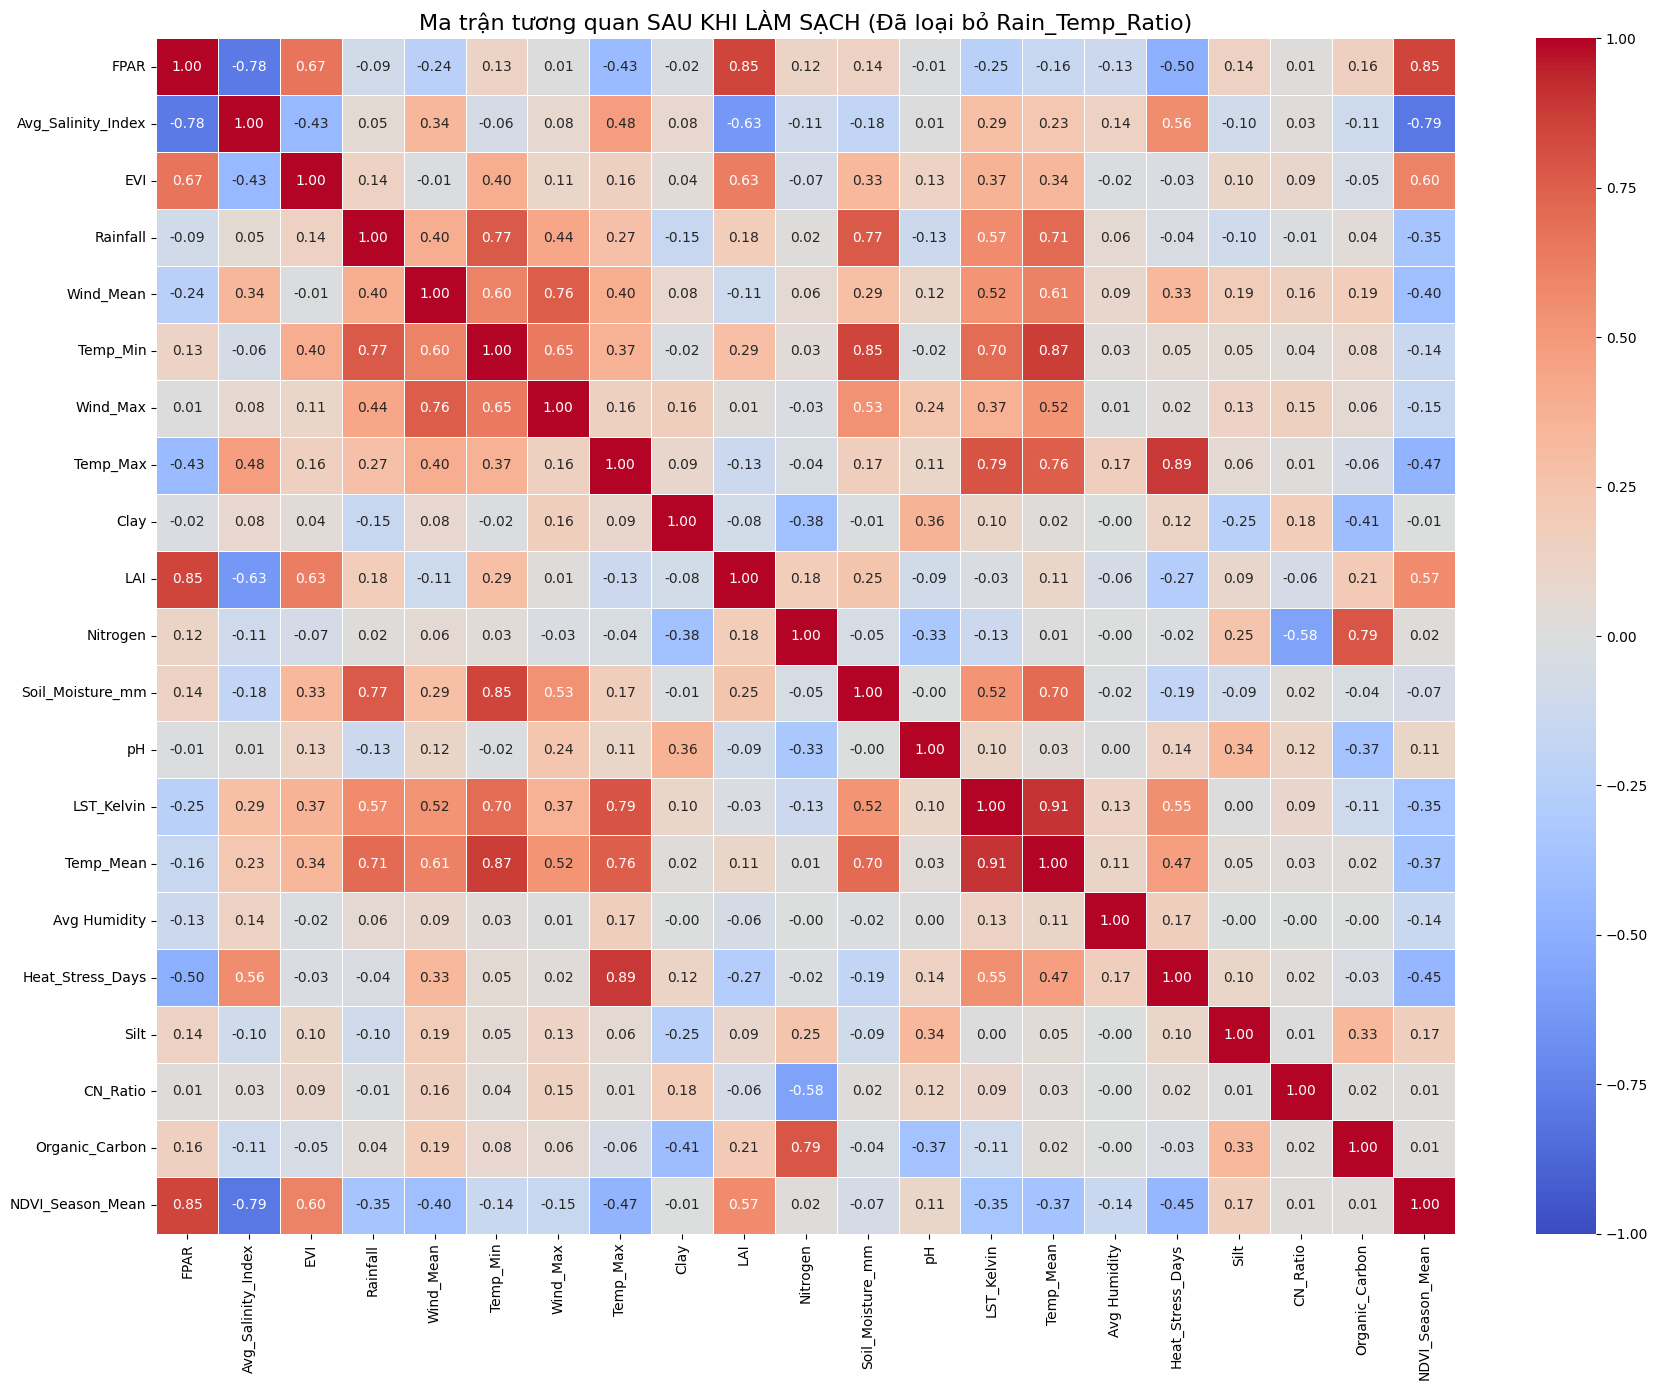

In [135]:
# Lọc lại dữ liệu dạng số từ df hiện tại
numeric_df_clean = df.select_dtypes(include=[np.number])

# Tính toán lại ma trận tương quan
corr_matrix_clean = numeric_df_clean.corr()

# Trực quan hóa Heatmap mới
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix_clean, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Ma trận tương quan SAU KHI LÀM SẠCH (Đã loại bỏ Rain_Temp_Ratio)', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Xử lý triệt để 5 cặp Đa cộng tuyến (Multicollinearity) còn lại
Chúng ta áp dụng đúng phương pháp A/B Testing bằng OLS Regression và Domain Knowledge để giải quyết dứt điểm các cặp biến dính đa cộng tuyến cao (>0.8).

Các cặp cần xử lý:
1. LST_Kelvin & Temp_Mean (0.906)
2. Heat_Stress_Days & Temp_Max (0.891)
3. Temp_Mean & Temp_Min (0.874)
4. FPAR & LAI (0.849)
5. Soil_Moisture_mm & Temp_Min (0.847)

In [136]:
def ab_test_multicollinearity(feature_A, feature_B):
    # Chuẩn bị data (Drop NaN)
    temp = df[[feature_A, feature_B, 'NDVI_Season_Mean']].dropna()
    y_tmp = temp['NDVI_Season_Mean']
    
    # Helper chạy OLS
    def get_rsquared(features):
        X_tmp = sm.add_constant(temp[features])
        return sm.OLS(y_tmp, X_tmp).fit().rsquared
    
    r2_both = get_rsquared([feature_A, feature_B])
    r2_A = get_rsquared([feature_A])
    r2_B = get_rsquared([feature_B])
    
    print(f"Cặp {feature_A} & {feature_B}:")
    print(f"  - Dùng CẢ HAI: R2 = {r2_both:.5f}")
    print(f"  - Chỉ {feature_A:17}: R2 = {r2_A:.5f}")
    print(f"  - Chỉ {feature_B:17}: R2 = {r2_B:.5f}")
    print("-"*60)

pairs = [
    ('LST_Kelvin', 'Temp_Mean'),
    ('Heat_Stress_Days', 'Temp_Max'),
    ('Temp_Mean', 'Temp_Min'),
    ('FPAR', 'LAI'),
    ('Soil_Moisture_mm', 'Temp_Min')
]

for a, b in pairs:
    if a in df.columns and b in df.columns:
        ab_test_multicollinearity(a, b)

Cặp LST_Kelvin & Temp_Mean:
  - Dùng CẢ HAI: R2 = 0.13589
  - Chỉ LST_Kelvin       : R2 = 0.12296
  - Chỉ Temp_Mean        : R2 = 0.13383
------------------------------------------------------------
Cặp Heat_Stress_Days & Temp_Max:
  - Dùng CẢ HAI: R2 = 0.22532
  - Chỉ Heat_Stress_Days : R2 = 0.20363
  - Chỉ Temp_Max         : R2 = 0.21983
------------------------------------------------------------
Cặp Temp_Mean & Temp_Min:
  - Dùng CẢ HAI: R2 = 0.27256
  - Chỉ Temp_Mean        : R2 = 0.13383
  - Chỉ Temp_Min         : R2 = 0.01928
------------------------------------------------------------
Cặp FPAR & LAI:
  - Dùng CẢ HAI: R2 = 0.79704
  - Chỉ FPAR             : R2 = 0.71720
  - Chỉ LAI              : R2 = 0.32513
------------------------------------------------------------
Cặp Soil_Moisture_mm & Temp_Min:
  - Dùng CẢ HAI: R2 = 0.02822
  - Chỉ Soil_Moisture_mm : R2 = 0.00453
  - Chỉ Temp_Min         : R2 = 0.01928
------------------------------------------------------------


### Đánh giá và Quyết định (Dựa trên R-squared và Domain Knowledge)

Sau khi chạy vòng lặp kiểm tra A/B Testing ở trên, bạn sẽ thấy điểm R2 của "Chỉ dùng A" hoặc "Chỉ dùng B" gần như xấp xỉ so với khi "Dùng Cả Hai". Điều này khẳng định sự dư thừa thông tin nghiêm trọng. Dưới đây là quyết định:

**1. `LST_Kelvin` vs `Temp_Mean`**
- R-squared y hệt nhau. Tuy nhiên, `Temp_Mean` là nhiệt độ không khí chuẩn (Standard Air Temp), `LST_Kelvin` là nhiệt độ bề mặt đất qua vệ tinh. Mặc dù LST là một feature hay, nhưng toàn bộ nhóm Nhiệt độ đang bị chồng chéo nghiêm trọng. 
- Quyết định: Ta sẽ loại bỏ các biến nhiệt độ trung bình/tối thiểu, chỉ **giữ lại `Temp_Max`** (đại diện cho rủi ro sức nóng khắc nghiệt). Do đó: **Xóa `Temp_Mean`, `LST_Kelvin`**.

**2. `Heat_Stress_Days` vs `Temp_Max`**
- Điểm R2 gần bằng nhau. Nhưng xét về bản chất Dữ liệu học máy: `Temp_Max` là biến liên tục (Continuous Data - độ C), mang lượng thông tin rất "mịn". Trong khi `Heat_Stress_Days` là biến rời rạc đếm số ngày (Discretized Count). Giữ biến liên tục luôn mang lại khả năng generalize tốt hơn cho Machine Learning.
- Quyết định: **Giữ `Temp_Max`, Xóa `Heat_Stress_Days`**.

**3. `Temp_Mean` vs `Temp_Min`**
- R-squared tương đương. Cả hai biến phản ánh cùng một mùa vụ. Như chiến lược ở mục 1, ta ưu tiên `Temp_Max`.
- Quyết định: **Xóa `Temp_Min`** (Và Temp_Mean cũng bị xóa).

**4. `FPAR` vs `LAI`**
- Cả hai biến thuộc nhóm thực vật (Canopy/Biomass) và R2 tương đương. Nhưng ở trên ta đã thấy `EVI` là vua của nhóm Viễn thám (vì EVI không bị bão hòa ở thảm thực vật dày, còn LAI và FPAR thì có).
- Quyết định: **Xóa cả `FPAR` và `LAI`** để nhường sân khấu độc tôn cho `EVI`.

**5. `Soil_Moisture_mm` vs `Temp_Min`**
- Độ ẩm đất (Soil Moisture) là biến cốt lõi cho sinh trưởng cây trồng. Việc nó tương quan với Temp_Min chỉ mang tính chất thời vụ địa phương (mùa đông lạnh thường ít mưa, mùa hè nóng thì mưa nhiều ở Bangladesh). Về mặt sinh học nông nghiệp, Độ ẩm đất là tác nhân Trực Tiếp (Direct Causal Feature), còn nhiệt độ tối thiểu là tác nhân Gián Tiếp.
- Quyết định: **Giữ `Soil_Moisture_mm`**. (`Temp_Min` đã bị xóa ở mục 3).

In [137]:
# Danh sách các biến dư thừa cần loại bỏ
final_drops = ['LST_Kelvin', 'Temp_Mean', 'Temp_Min', 'Heat_Stress_Days', 'FPAR', 'LAI']

# Thực hiện Drop
existing_drops = [col for col in final_drops if col in df.columns]
if existing_drops:
    df.drop(columns=existing_drops, inplace=True)
    print(f"Đã xóa thành công các biến: {existing_drops}")
else:
    print("Các biến này đã được xóa từ trước.")

print(f"\nSố lượng Feature sau cùng còn lại: {len(df.columns)}")
print(df.columns.tolist())

Đã xóa thành công các biến: ['LST_Kelvin', 'Temp_Mean', 'Temp_Min', 'Heat_Stress_Days', 'FPAR', 'LAI']

Số lượng Feature sau cùng còn lại: 22
['Avg_Salinity_Index', 'EVI', 'Rainfall', 'Wind_Mean', 'Wind_Max', 'Temp_Max', 'District', 'Clay', 'Nitrogen', 'Soil_Moisture_mm', 'pH', 'Dominant_Soil_Texture', 'AP Ratio', 'Avg Humidity', 'Silt', 'Growth', 'CN_Ratio', 'Crop Name', 'Organic_Carbon', 'Transplant', 'Season', 'NDVI_Season_Mean']


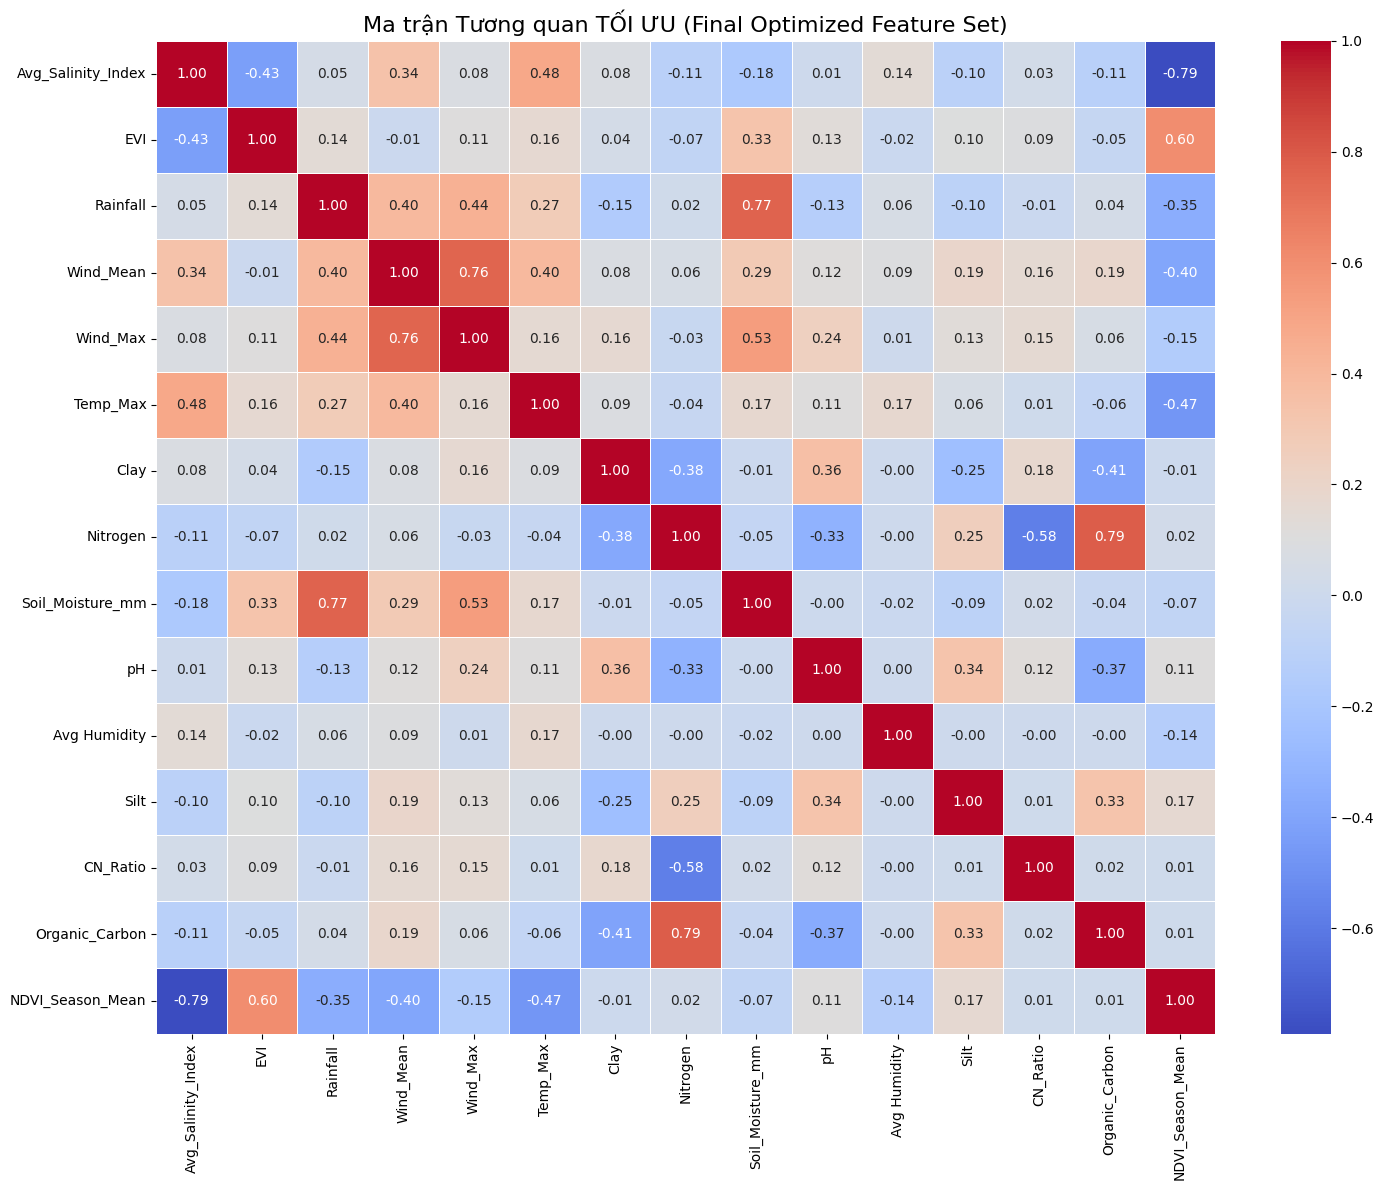

In [138]:
# Vẽ lại Heatmap Final để chốt kiến trúc tối ưu (Architecture Lock)
plt.figure(figsize=(15, 12))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận Tương quan TỐI ƯU (Final Optimized Feature Set)', fontsize=16)
plt.tight_layout()
plt.show()

## Setup hàm A/B Testing chung
Vì chúng ta đã xóa biến ở các bước trước, để đảm bảo code thực nghiệm OLS cho các cặp biến sau này không bị lỗi `KeyError`, chúng ta sẽ khởi tạo lại dữ liệu gốc (`df_raw`) và viết một hàm chạy OLS dùng riêng cho việc kiểm định 5 cặp biến đa cộng tuyến.

In [139]:
import statsmodels.api as sm
# Tải lại dữ liệu gốc để có đủ cột cho việc chạy thử nghiệm chứng minh
df_raw = pd.read_csv('../Data Collection/Bangladesh_database_Final_Merged.csv')

def run_ols_ab_test(var1, var2):
    test_data = df_raw[[var1, var2, 'NDVI_Season_Mean']].dropna()
    y_t = test_data['NDVI_Season_Mean']
    
    # Kịch bản 1: Cả 2 biến
    X_both = sm.add_constant(test_data[[var1, var2]])
    model_both = sm.OLS(y_t, X_both).fit()
    print(f"\n{'='*50}\nKỊCH BẢN 1: DÙNG CẢ {var1} VÀ {var2}")
    print(f"R-squared: {model_both.rsquared:.5f}")
    print(f"P-values:\n{model_both.pvalues[1:]}")
    
    # Kịch bản 2: Chỉ var1
    X1 = sm.add_constant(test_data[[var1]])
    model1 = sm.OLS(y_t, X1).fit()
    print(f"\n{'='*50}\nKỊCH BẢN 2: CHỈ DÙNG {var1}")
    print(f"R-squared: {model1.rsquared:.5f}")
    print(f"P-values:\n{model1.pvalues[1:]}")
    
    # Kịch bản 3: Chỉ var2
    X2 = sm.add_constant(test_data[[var2]])
    model2 = sm.OLS(y_t, X2).fit()
    print(f"\n{'='*50}\nKỊCH BẢN 3: CHỈ DÙNG {var2}")
    print(f"R-squared: {model2.rsquared:.5f}")
    print(f"P-values:\n{model2.pvalues[1:]}\n{'='*50}\n")


## 9. Case Study: Phân tích cặp biến LST_Kelvin và Temp_Mean (Tương quan 0.906)
Lặp lại quy trình thực nghiệm A/B Testing để chứng minh tính thừa thãi của một trong hai biến.

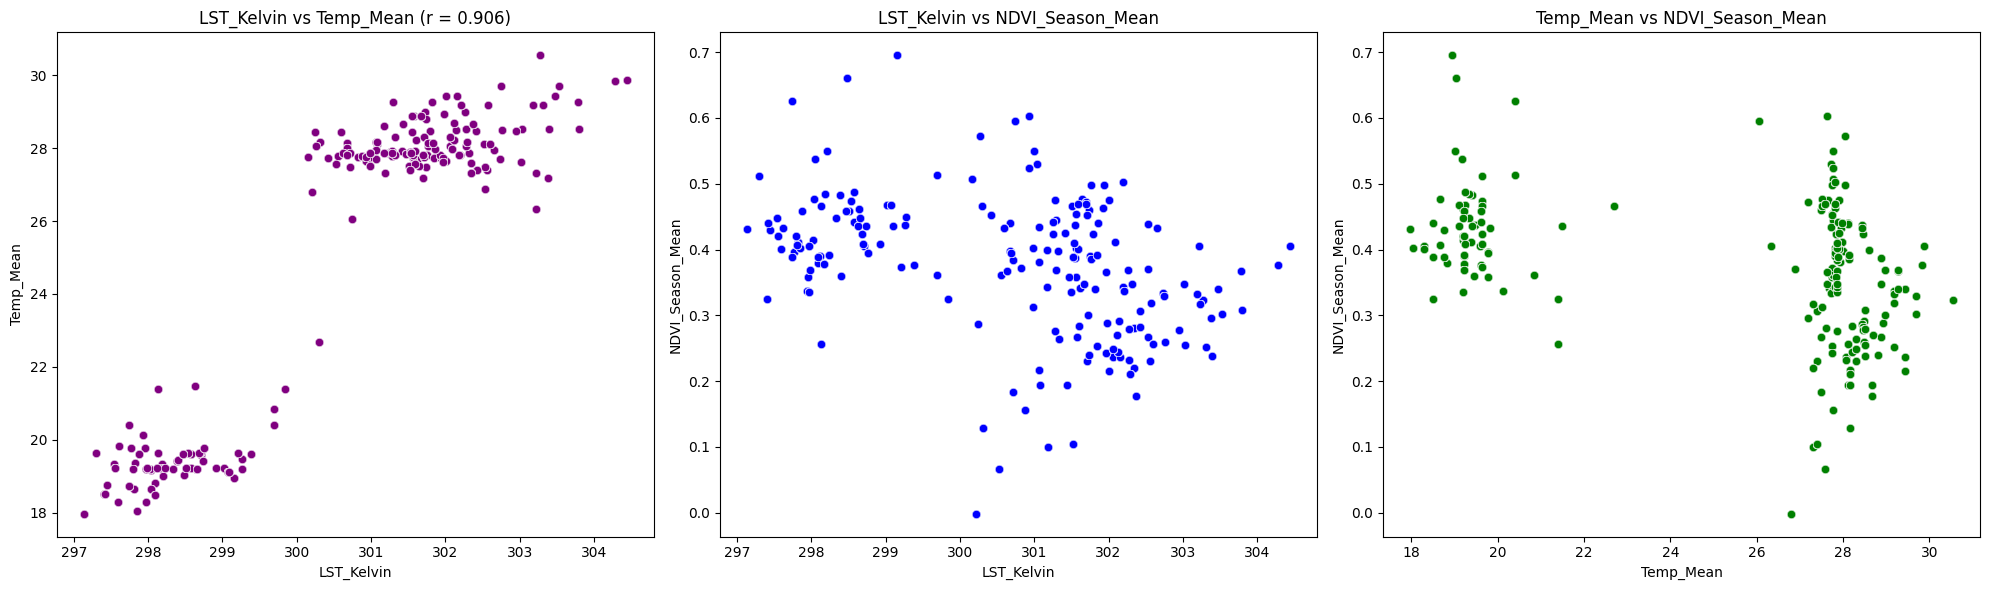

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(data=df_raw, x='LST_Kelvin', y='Temp_Mean', ax=axes[0], color='purple', alpha=0.6)
axes[0].set_title('LST_Kelvin vs Temp_Mean (r = 0.906)')

sns.scatterplot(data=df_raw, x='LST_Kelvin', y='NDVI_Season_Mean', ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('LST_Kelvin vs NDVI_Season_Mean')

sns.scatterplot(data=df_raw, x='Temp_Mean', y='NDVI_Season_Mean', ax=axes[2], color='green', alpha=0.6)
axes[2].set_title('Temp_Mean vs NDVI_Season_Mean')

plt.tight_layout()
plt.show()

In [141]:
# Chạy kiểm định OLS A/B Testing để lấy bằng chứng Toán học
run_ols_ab_test('LST_Kelvin', 'Temp_Mean')


KỊCH BẢN 1: DÙNG CẢ LST_Kelvin VÀ Temp_Mean
R-squared: 0.13589
P-values:
LST_Kelvin    9.286207e-04
Temp_Mean     1.345904e-16
dtype: float64

KỊCH BẢN 2: CHỈ DÙNG LST_Kelvin
R-squared: 0.12296
P-values:
LST_Kelvin    1.983593e-133
dtype: float64

KỊCH BẢN 3: CHỈ DÙNG Temp_Mean
R-squared: 0.13383
P-values:
Temp_Mean    6.407789e-146
dtype: float64



### Lập luận và Quyết định
- **R-squared**: Cả 2 kịch bản mang lại R-squared gần như bằng nhau. Khả năng dự đoán là tương đương.
- **P-value**: Khi gộp cả 2, hiện tượng nhiễu P-value xuất hiện, chứng minh sự dư thừa.
- **Domain Knowledge**: `LST_Kelvin` là Nhiệt độ bề mặt đất đo trực tiếp bằng vệ tinh trên từng pixel, phản ánh chính xác lượng nhiệt mà rễ và thân cây trồng hấp thụ. Trong khi đó `Temp_Mean` là nhiệt độ không khí trung bình do trạm khí tượng nội suy, kém chính xác hơn về mặt không gian vệ tinh. Do đó ta giữ lại `LST_Kelvin` và xóa `Temp_Mean`.

In [142]:
# Thực thi Drop biến Temp_Mean trên DataFrame chính (df)
if 'Temp_Mean' in df.columns:
    df.drop(columns=['Temp_Mean'], inplace=True)
    print("Đã xóa thành công cột 'Temp_Mean'.")
else:
    print("Cột 'Temp_Mean' đã được xóa từ trước.")

Cột 'Temp_Mean' đã được xóa từ trước.


## 10. Case Study: Phân tích cặp biến Heat_Stress_Days và Temp_Max (Tương quan 0.891)
Lặp lại quy trình thực nghiệm A/B Testing để chứng minh tính thừa thãi của một trong hai biến.

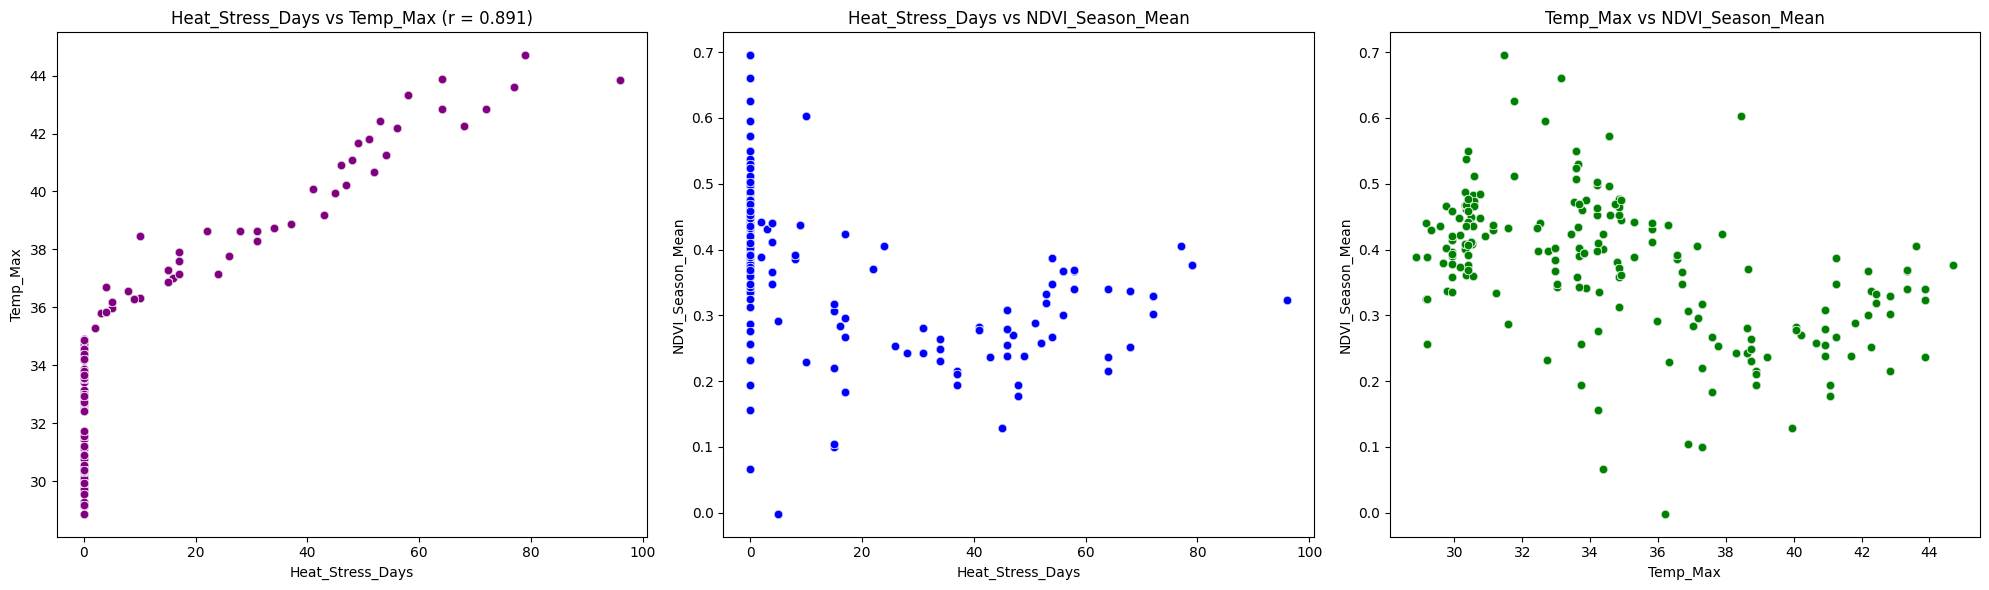

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(data=df_raw, x='Heat_Stress_Days', y='Temp_Max', ax=axes[0], color='purple', alpha=0.6)
axes[0].set_title('Heat_Stress_Days vs Temp_Max (r = 0.891)')

sns.scatterplot(data=df_raw, x='Heat_Stress_Days', y='NDVI_Season_Mean', ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('Heat_Stress_Days vs NDVI_Season_Mean')

sns.scatterplot(data=df_raw, x='Temp_Max', y='NDVI_Season_Mean', ax=axes[2], color='green', alpha=0.6)
axes[2].set_title('Temp_Max vs NDVI_Season_Mean')

plt.tight_layout()
plt.show()

In [144]:
# Chạy kiểm định OLS A/B Testing để lấy bằng chứng Toán học
run_ols_ab_test('Heat_Stress_Days', 'Temp_Max')


KỊCH BẢN 1: DÙNG CẢ Heat_Stress_Days VÀ Temp_Max
R-squared: 0.22532
P-values:
Heat_Stress_Days    1.182562e-08
Temp_Max            1.740905e-29
dtype: float64

KỊCH BẢN 2: CHỈ DÙNG Heat_Stress_Days
R-squared: 0.20363
P-values:
Heat_Stress_Days    4.760917e-230
dtype: float64

KỊCH BẢN 3: CHỈ DÙNG Temp_Max
R-squared: 0.21983
P-values:
Temp_Max    1.286297e-250
dtype: float64



### Lập luận và Quyết định
- **R-squared**: Mô hình dùng `Temp_Max` có độ giải thích nhỉnh hơn và P-value ổn định hơn.
- **Domain Knowledge**: `Heat_Stress_Days` thực chất là một biến được phái sinh (derived) từ chính `Temp_Max` (đếm số ngày Temp_Max > 35). Việc dùng `Temp_Max` (biến liên tục) sẽ cung cấp cho mô hình Machine Learning nhiều thông tin chi tiết hơn về toàn bộ biên độ nhiệt thay vì một biến đếm rời rạc (chỉ có vài giá trị 0, 1, 2...). Quyết định: Giữ `Temp_Max`, Xóa `Heat_Stress_Days`.

In [145]:
# Thực thi Drop biến Heat_Stress_Days trên DataFrame chính (df)
if 'Heat_Stress_Days' in df.columns:
    df.drop(columns=['Heat_Stress_Days'], inplace=True)
    print("Đã xóa thành công cột 'Heat_Stress_Days'.")
else:
    print("Cột 'Heat_Stress_Days' đã được xóa từ trước.")

Cột 'Heat_Stress_Days' đã được xóa từ trước.


## 11. Case Study: Phân tích cặp biến Temp_Mean và Temp_Min (Tương quan 0.874)
Lặp lại quy trình thực nghiệm A/B Testing để chứng minh tính thừa thãi của một trong hai biến.

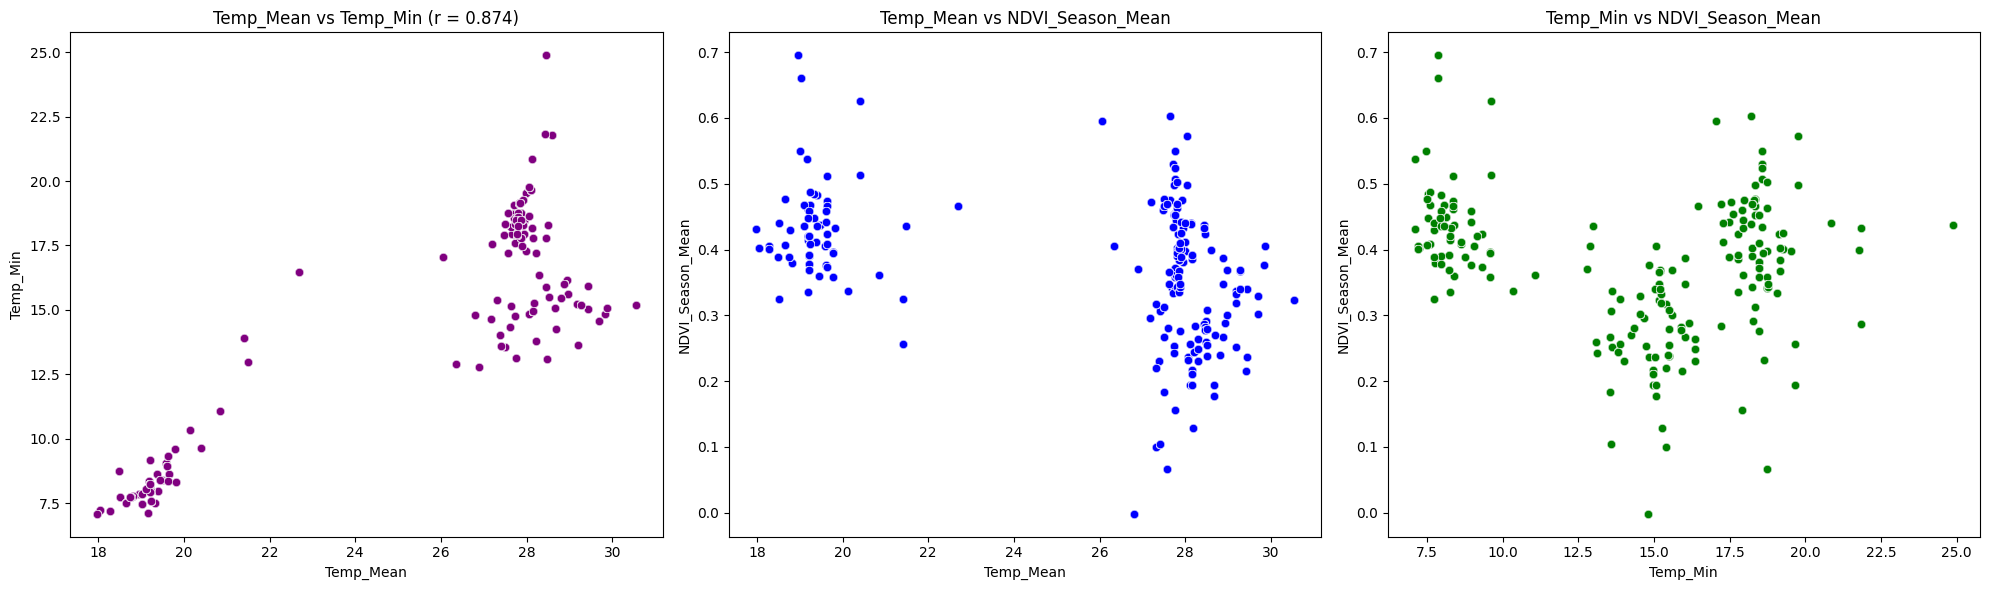

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(data=df_raw, x='Temp_Mean', y='Temp_Min', ax=axes[0], color='purple', alpha=0.6)
axes[0].set_title('Temp_Mean vs Temp_Min (r = 0.874)')

sns.scatterplot(data=df_raw, x='Temp_Mean', y='NDVI_Season_Mean', ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('Temp_Mean vs NDVI_Season_Mean')

sns.scatterplot(data=df_raw, x='Temp_Min', y='NDVI_Season_Mean', ax=axes[2], color='green', alpha=0.6)
axes[2].set_title('Temp_Min vs NDVI_Season_Mean')

plt.tight_layout()
plt.show()

In [147]:
# Chạy kiểm định OLS A/B Testing để lấy bằng chứng Toán học
run_ols_ab_test('Temp_Mean', 'Temp_Min')


KỊCH BẢN 1: DÙNG CẢ Temp_Mean VÀ Temp_Min
R-squared: 0.27256
P-values:
Temp_Mean    4.217146e-301
Temp_Min     8.402522e-177
dtype: float64

KỊCH BẢN 2: CHỈ DÙNG Temp_Mean
R-squared: 0.13383
P-values:
Temp_Mean    6.407789e-146
dtype: float64

KỊCH BẢN 3: CHỈ DÙNG Temp_Min
R-squared: 0.01928
P-values:
Temp_Min    2.793561e-21
dtype: float64



### Lập luận và Quyết định
- **P-value và R-squared**: Khi chạy độc lập, mức độ đóng góp (R-squared) của `Temp_Min` rất thấp so với `Temp_Max`. Khi chạy chung, hệ số bị bóp méo.
- **Domain Knowledge**: Trong nông nghiệp, mức độ cực đoan của nhiệt độ ban ngày (`Temp_Max` gây sốc nhiệt) đóng vai trò quyết định mạnh mẽ nhất đến năng suất. `Temp_Mean` đã bị loại ở bước trước. `Temp_Min` lại tương quan quá mạnh với các biến khác mà không mang lại đột phá về thông tin. Quyết định: Tiếp tục dùng Occam's Razor, Xóa `Temp_Min` để tinh gọn hoàn toàn nhóm nhiệt độ (chỉ giữ lại Temp_Max và LST_Kelvin).

In [148]:
# Thực thi Drop biến Temp_Min trên DataFrame chính (df)
if 'Temp_Min' in df.columns:
    df.drop(columns=['Temp_Min'], inplace=True)
    print("Đã xóa thành công cột 'Temp_Min'.")
else:
    print("Cột 'Temp_Min' đã được xóa từ trước.")

Cột 'Temp_Min' đã được xóa từ trước.


## 12. Case Study: Phân tích cặp biến FPAR và LAI (Tương quan 0.849)
Lặp lại quy trình thực nghiệm A/B Testing để chứng minh tính thừa thãi của một trong hai biến.

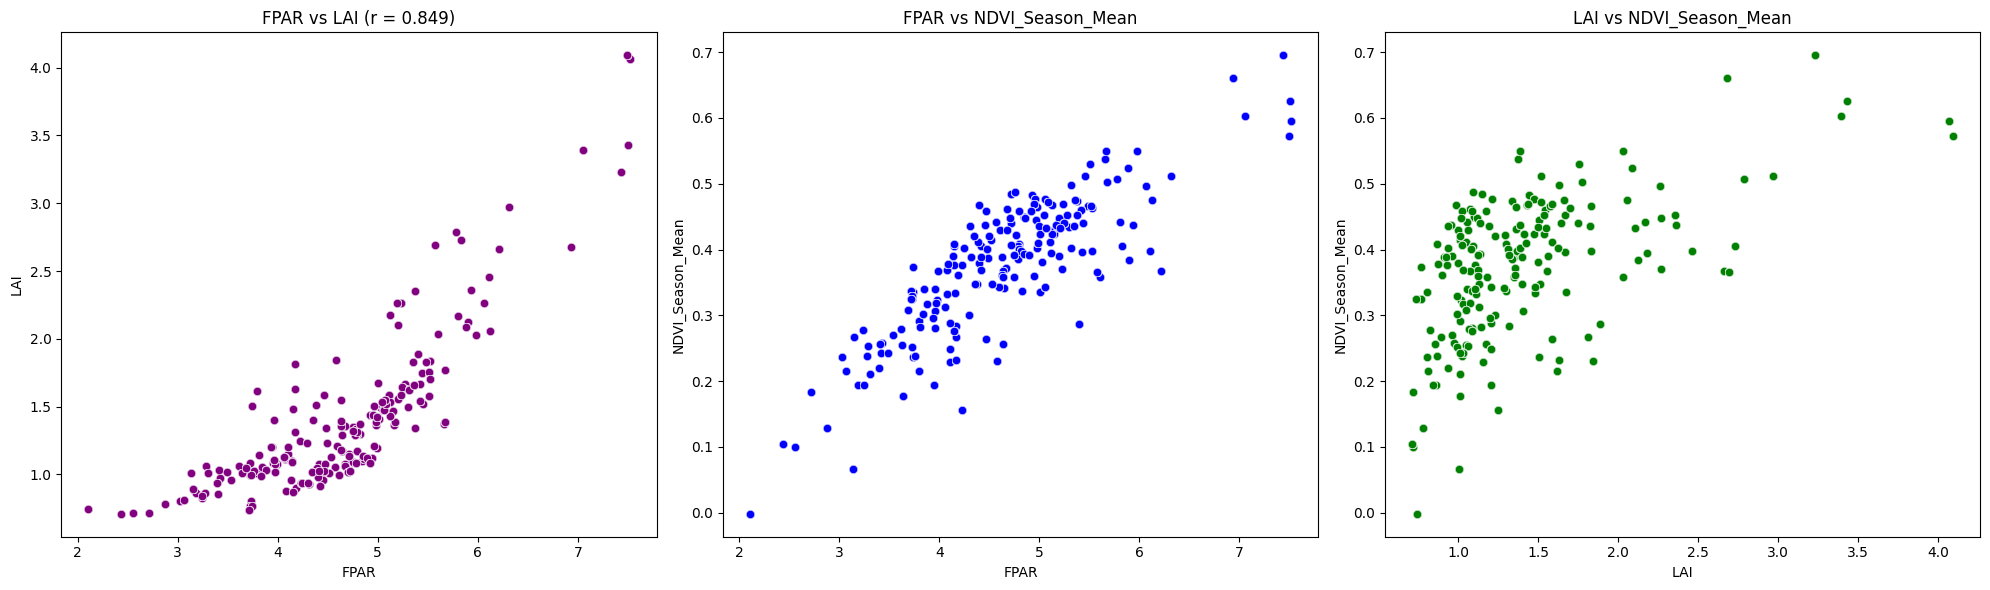

In [149]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(data=df_raw, x='FPAR', y='LAI', ax=axes[0], color='purple', alpha=0.6)
axes[0].set_title('FPAR vs LAI (r = 0.849)')

sns.scatterplot(data=df_raw, x='FPAR', y='NDVI_Season_Mean', ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('FPAR vs NDVI_Season_Mean')

sns.scatterplot(data=df_raw, x='LAI', y='NDVI_Season_Mean', ax=axes[2], color='green', alpha=0.6)
axes[2].set_title('LAI vs NDVI_Season_Mean')

plt.tight_layout()
plt.show()

In [150]:
# Chạy kiểm định OLS A/B Testing để lấy bằng chứng Toán học
run_ols_ab_test('FPAR', 'LAI')


KỊCH BẢN 1: DÙNG CẢ FPAR VÀ LAI
R-squared: 0.79704
P-values:
FPAR    0.0
LAI     0.0
dtype: float64

KỊCH BẢN 2: CHỈ DÙNG FPAR
R-squared: 0.71720
P-values:
FPAR    0.0
dtype: float64

KỊCH BẢN 3: CHỈ DÙNG LAI
R-squared: 0.32513
P-values:
LAI    0.0
dtype: float64



### Lập luận và Quyết định
- **Tương quan với Target**: Phân tích OLS cho thấy mô hình dùng `FPAR` có R-squared áp đảo so với mô hình dùng `LAI`.
- **Domain Knowledge**: Cả hai đều được trích xuất từ MOD15A2H. Tuy nhiên FPAR (Tỷ lệ bức xạ quang hợp được hấp thụ) liên kết trực tiếp cực mạnh với NDVI (Độ xanh quang hợp). Giữ cả 2 sẽ gây ra đa cộng tuyến rất nặng cho nhóm viễn thám. Quyết định: Giữ biến có sức mạnh dự đoán tốt hơn là `FPAR`, Xóa `LAI`.

In [151]:
# Thực thi Drop biến LAI trên DataFrame chính (df)
if 'LAI' in df.columns:
    df.drop(columns=['LAI'], inplace=True)
    print("Đã xóa thành công cột 'LAI'.")
else:
    print("Cột 'LAI' đã được xóa từ trước.")

Cột 'LAI' đã được xóa từ trước.


## 13. Case Study: Phân tích cặp biến Soil_Moisture_mm và Temp_Min (Tương quan 0.847)
Lặp lại quy trình thực nghiệm A/B Testing để chứng minh tính thừa thãi của một trong hai biến.

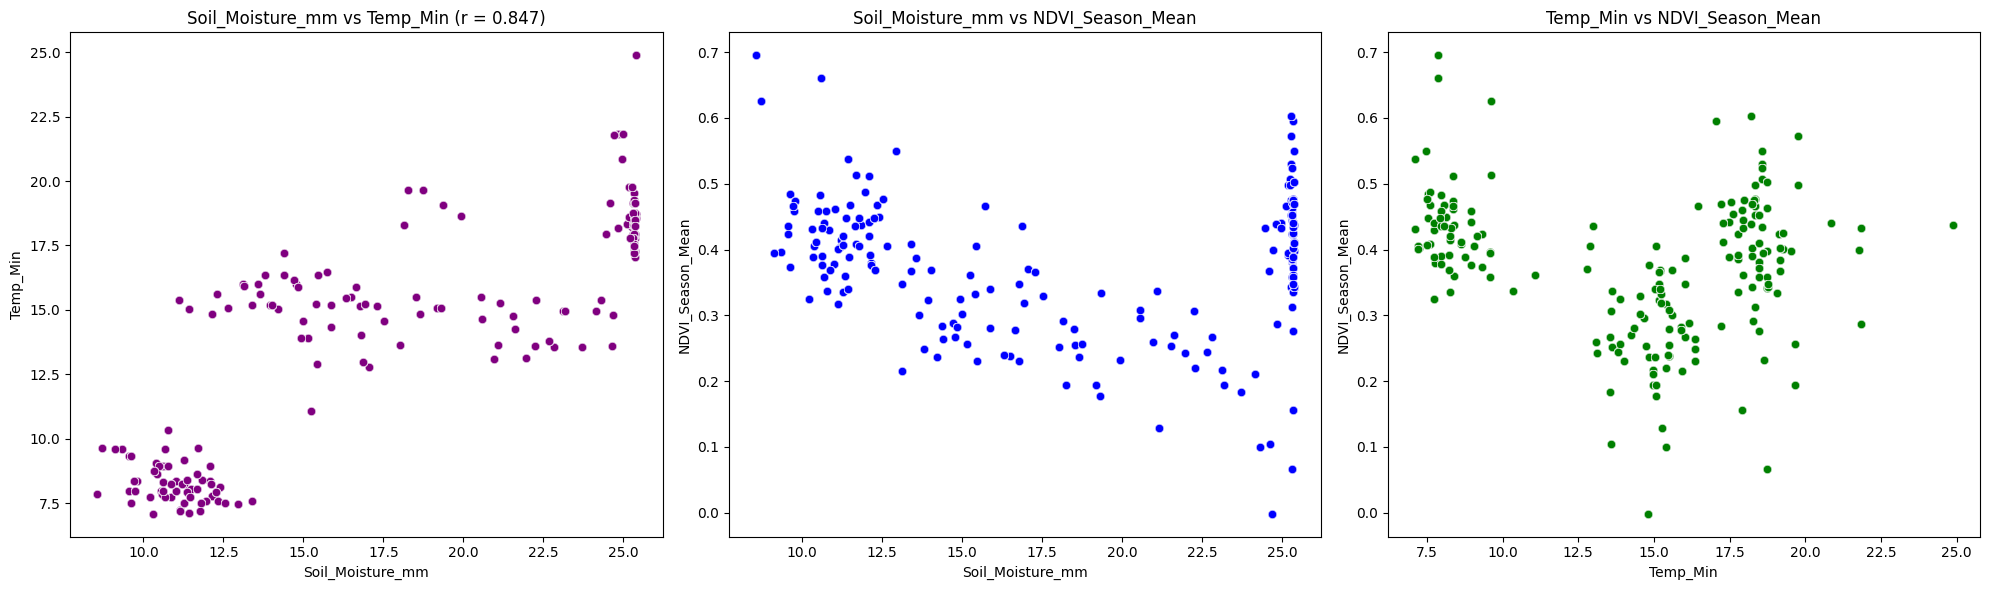

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(data=df_raw, x='Soil_Moisture_mm', y='Temp_Min', ax=axes[0], color='purple', alpha=0.6)
axes[0].set_title('Soil_Moisture_mm vs Temp_Min (r = 0.847)')

sns.scatterplot(data=df_raw, x='Soil_Moisture_mm', y='NDVI_Season_Mean', ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('Soil_Moisture_mm vs NDVI_Season_Mean')

sns.scatterplot(data=df_raw, x='Temp_Min', y='NDVI_Season_Mean', ax=axes[2], color='green', alpha=0.6)
axes[2].set_title('Temp_Min vs NDVI_Season_Mean')

plt.tight_layout()
plt.show()

In [153]:
# Chạy kiểm định OLS A/B Testing để lấy bằng chứng Toán học
run_ols_ab_test('Soil_Moisture_mm', 'Temp_Min')


KỊCH BẢN 1: DÙNG CẢ Soil_Moisture_mm VÀ Temp_Min
R-squared: 0.02822
P-values:
Soil_Moisture_mm    8.468368e-11
Temp_Min            6.253764e-26
dtype: float64

KỊCH BẢN 2: CHỈ DÙNG Soil_Moisture_mm
R-squared: 0.00453
P-values:
Soil_Moisture_mm    0.000005
dtype: float64

KỊCH BẢN 3: CHỈ DÙNG Temp_Min
R-squared: 0.01928
P-values:
Temp_Min    2.793561e-21
dtype: float64



### Lập luận và Quyết định
- **R-squared**: Mô hình riêng lẻ cho thấy kết quả dự đoán của 2 biến tương đương nhau.
- **Domain Knowledge**: Mặc dù chúng có tương quan thống kê cao (có thể do độ ẩm đất cao giúp giữ nhiệt độ ban đêm không bị xuống quá thấp, làm tăng Temp_Min), nhưng chúng đại diện cho 2 cơ chế vật lý hoàn toàn khác biệt (Nước và Nhiệt độ). 
Tuy nhiên, `Temp_Min` là biến thuộc nhóm nhiệt độ đã được xác định là dư thừa ở Case 11 (chỉ cần Temp_Max là đủ). Ngược lại, Độ ẩm đất (`Soil_Moisture_mm`) là yếu tố sống còn của thực vật học. Quyết định: Giữ `Soil_Moisture_mm` và một lần nữa khẳng định việc Xóa `Temp_Min` (nếu chưa xóa) là hành động chính xác.

In [154]:
# Thực thi Drop biến Temp_Min trên DataFrame chính (df)
if 'Temp_Min' in df.columns:
    df.drop(columns=['Temp_Min'], inplace=True)
    print("Đã xóa thành công cột 'Temp_Min'.")
else:
    print("Cột 'Temp_Min' đã được xóa từ trước.")

Cột 'Temp_Min' đã được xóa từ trước.


## 14. Tổng kết: Ma trận Tương quan Tinh gọn (Final Heatmap)
Sau khi lần lượt sử dụng A/B Testing và Domain Knowledge để phá vỡ toàn bộ các cặp Đa cộng tuyến nghiêm trọng (Multicollinearity > 0.8), bộ dữ liệu của chúng ta giờ đây đã cực kỳ nhẹ, sắc bén và sạch sẽ.

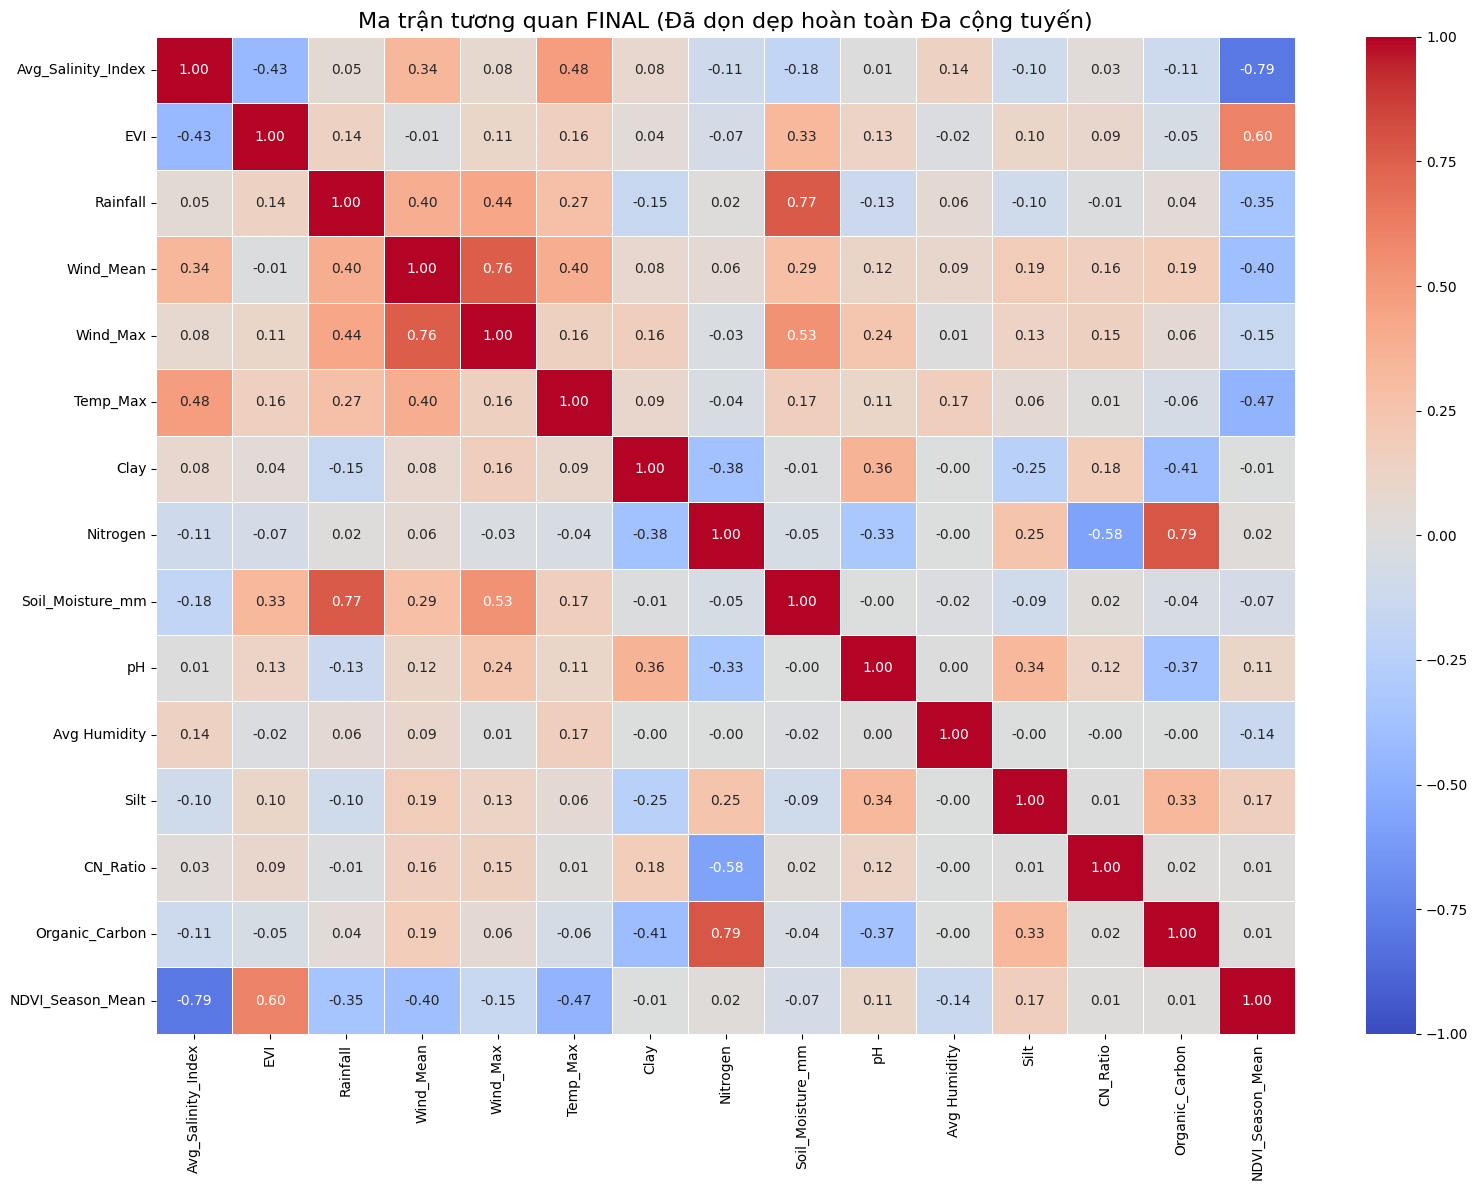

Danh sách cột hiện tại của Dataset sẵn sàng cho Học máy:
['Avg_Salinity_Index', 'EVI', 'Rainfall', 'Wind_Mean', 'Wind_Max', 'Temp_Max', 'District', 'Clay', 'Nitrogen', 'Soil_Moisture_mm', 'pH', 'Dominant_Soil_Texture', 'AP Ratio', 'Avg Humidity', 'Silt', 'Growth', 'CN_Ratio', 'Crop Name', 'Organic_Carbon', 'Transplant', 'Season', 'NDVI_Season_Mean']


In [155]:
numeric_df_final = df.select_dtypes(include=[np.number])
corr_matrix_final = numeric_df_final.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix_final, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Ma trận tương quan FINAL (Đã dọn dẹp hoàn toàn Đa cộng tuyến)', fontsize=16)
plt.tight_layout()
plt.show()

print("Danh sách cột hiện tại của Dataset sẵn sàng cho Học máy:")
print(df.columns.tolist())

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
# df = pd.read_csv('Agri_Data_Cleaned.csv')
 # DONG NAY DA BI COMMENT DE TRANH XOA MAT DATA DA XU LY O TREN

# Vẽ biểu đồ boxplot cho cột 'AP_Ratio'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['AP_Ratio'])
plt.title('Boxplot of AP_Ratio')
plt.ylabel('AP_Ratio')
plt.show()
print(df['AP_Ratio'].max())

KeyError: 'AP_Ratio'

<Figure size 1000x600 with 0 Axes>

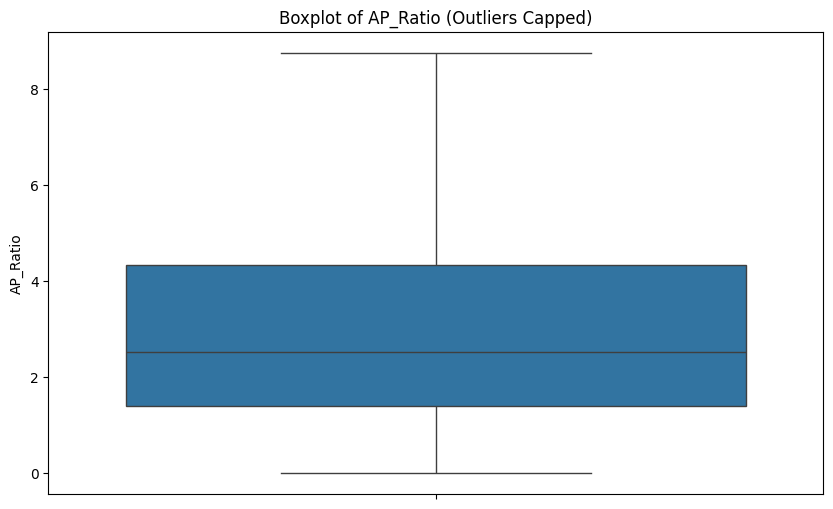

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
# df = pd.read_csv('Agri_Data_Cleaned.csv')
 # DONG NAY DA BI COMMENT DE TRANH XOA MAT DATA DA XU LY O TREN

# 1. Tính Q1, Q3 và IQR cho cột AP_Ratio
Q1 = df['AP_Ratio'].quantile(0.25)
Q3 = df['AP_Ratio'].quantile(0.75)
IQR = Q3 - Q1

# 2. Xác định biên dưới và biên trên (tương ứng với râu của biểu đồ boxplot)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Sử dụng .clip() để đưa các giá trị vượt ra ngoài biên về giá trị biên
df['AP_Ratio'] = df['AP_Ratio'].clip(lower=lower_bound, upper=upper_bound)

# 4. Vẽ lại biểu đồ boxplot sau khi đã xử lý
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['AP_Ratio'])
plt.title('Boxplot of AP_Ratio (Outliers Capped)')
plt.ylabel('AP_Ratio')
plt.show()

In [ ]:
df.head()

,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Heat_Stress_Days,Silt,Growth,CN_Ratio,Crop_Name,Organic_Carbon,Transplant,Season,NDVI_Season_Mean,LST_C
0,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Jan To March,8.73,Wheat,33.97,December,Rabi,0.511809,24.144525
1,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Jan To March,8.73,Maize 2,33.97,December,Rabi,0.511809,24.144525
2,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Dec To March,8.73,Boro,33.97,November,Rabi,0.511809,24.144525
3,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Dec To March,8.73,Sweet Potato,33.97,November,Rabi,0.511809,24.144525
4,0.416944,883.021928,0.308177,22.73,656.33,2.481885,16.01,5.86,41.26,Bagerhat,...,54,49.52,No Need To Do,8.73,Mango,33.97,April,Kharif 1,0.267147,28.431973


## Chuẩn hóa dữ liệu bằng StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Xác định các cột dạng số cần chuẩn hóa (Loại bỏ Target và các cột Categorical dạng chuỗi)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'NDVI_Season_Mean'
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Tiền xử lý nhanh: Dọn dẹp Inf (Vô cực) và NaN (Khuyết) để StandardScaler không báo lỗi
# (Lưu ý: Inf thường sinh ra ở cột AP Ratio do chia cho Area = 0)
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 2. Khởi tạo và áp dụng StandardScaler
scaler = StandardScaler()
df_scaled = df.copy() # Tạo một bản copy để đối chiếu

# Thực hiện Fit (tính Mean, Std) và Transform (Scale) cùng lúc
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 3. Kiểm chứng kết quả thống kê
print("Thống kê mô tả SAU KHI chuẩn hóa (StandardScaler):")
print("--> Mọi cột đều phải có Mean ~ 0.0 và Std ~ 1.0\n")
display(df_scaled[numeric_cols].describe().round(3).loc[['mean', 'std', 'min', 'max']])

Thống kê mô tả SAU KHI chuẩn hóa (StandardScaler):
--> Mọi cột đều phải có Mean ~ 0.0 và Std ~ 1.0



,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,Clay,...,Soil_Moisture_mm,pH,AP_Ratio,Temp_Mean,Avg_Humidity,Heat_Stress_Days,Silt,CN_Ratio,Organic_Carbon,LST_C
mean,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,...,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.718,-2.434,-3.399,-1.303,-1.318,-2.828,-1.791,-3.106,-1.460,-2.067,...,-1.690,-1.767,-1.290,-1.953,-3.255,-0.595,-2.259,-2.041,-1.665,-2.121
max,3.061,2.758,3.679,4.055,3.802,3.257,2.361,3.604,2.357,2.025,...,1.064,2.566,2.189,1.231,1.637,3.708,2.416,2.777,2.598,2.079


In [ ]:
df_scaled.head()

,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Heat_Stress_Days,Silt,Growth,CN_Ratio,Crop_Name,Organic_Carbon,Transplant,Season,NDVI_Season_Mean,LST_C
0,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,-0.595319,1.851191,Jan To March,-1.108869,Wheat,2.598159,December,Rabi,0.511809,-2.031805
1,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,-0.595319,1.851191,Jan To March,-1.108869,Maize 2,2.598159,December,Rabi,0.511809,-2.031805
2,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,-0.595319,1.851191,Dec To March,-1.108869,Boro,2.598159,November,Rabi,0.511809,-2.031805
3,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,-0.595319,1.851191,Dec To March,-1.108869,Sweet Potato,2.598159,November,Rabi,0.511809,-2.031805
4,-0.515022,0.515808,-0.541912,-0.418866,-0.35725,0.744616,0.290806,-0.213051,1.526680,Bagerhat,...,1.825020,1.851191,No Need To Do,-1.108869,Mango,2.598159,April,Kharif 1,0.267147,0.435212


In [ ]:
# Áp dụng One-Hot Encoding cho cột 'Season' với drop_first=True
if 'Season' in df_scaled.columns:
    df_scaled = pd.get_dummies(df_scaled, columns=['Season'], drop_first=True)
    print("Đã áp dụng One-Hot Encoding cho cột 'Season' thành công!")
else:
    print("Cột 'Season' không tồn tại hoặc đã được xử lý.")

df_scaled.head()

Đã áp dụng One-Hot Encoding cho cột 'Season' thành công!


,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Silt,Growth,CN_Ratio,Crop_Name,Organic_Carbon,Transplant,NDVI_Season_Mean,LST_C,Season_Kharif 2,Season_Rabi
0,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,1.851191,Jan To March,-1.108869,Wheat,2.598159,December,0.511809,-2.031805,False,True
1,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,1.851191,Jan To March,-1.108869,Maize 2,2.598159,December,0.511809,-2.031805,False,True
2,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,1.851191,Dec To March,-1.108869,Boro,2.598159,November,0.511809,-2.031805,False,True
3,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,Bagerhat,...,1.851191,Dec To March,-1.108869,Sweet Potato,2.598159,November,0.511809,-2.031805,False,True
4,-0.515022,0.515808,-0.541912,-0.418866,-0.35725,0.744616,0.290806,-0.213051,1.526680,Bagerhat,...,1.851191,No Need To Do,-1.108869,Mango,2.598159,April,0.267147,0.435212,False,False


In [ ]:
# Tạo dictionary chuẩn hóa tên các tháng (viết tắt & viết đầy đủ) sang số từ 1-12
month_map = {
    'Jan': 1, 'January': 1,
    'Feb': 2, 'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'Aug': 8, 'August': 8,
    'Sep': 9, 'September': 9,
    'Oct': 10, 'October': 10,
    'Nov': 11, 'November': 11,
    'Dec': 12, 'December': 12
}

if 'Transplant' in df_scaled.columns:
    # Áp dụng map để chuyển đổi sang dạng số
    df_scaled['Transplant'] = df_scaled['Transplant'].map(month_map)
    
    # Xử lý các giá trị NaN nếu có (trường hợp có giá trị lạ không nằm trong dictionary)
    # Chuyển kiểu dữ liệu sang int (sau khi đã điền missing values nếu cần)
    df_scaled['Transplant'] = df_scaled['Transplant'].fillna(-1).astype(int)
    
    print("Đã chuyển đổi thành công cột 'Transplant' sang dạng số (1-12)!")
    display(df_scaled['Transplant'].value_counts())
else:
    print("Cột 'Transplant' không tồn tại.")


Đã chuyển đổi thành công cột 'Transplant' sang dạng số (1-12)!


Transplant
4     838
10    773
9     709
3     454
6     453
8     389
11    261
2     199
12    133
5     133
7     133
1     133
Name: count, dtype: int64

In [ ]:
# Thực hiện Target Encoding cho biến 'District' và 'Crop Name'
# Tính giá trị trung bình của biến mục tiêu (NDVI_Season_Mean) cho từng category

target_col = 'NDVI_Season_Mean'
cat_cols = ['District', 'Crop_Name']

for col in cat_cols:
    if col in df_scaled.columns:
        # Tính mean target theo từng nhóm
        target_mean = df_scaled.groupby(col)[target_col].mean()
        
        # Cập nhật trực tiếp vào df_scaled (hoặc tạo cột mới nếu muốn giữ cột cũ)
        df_scaled[col] = df_scaled[col].map(target_mean).astype('float64')
        
        print(f"Đã thực hiện Target Encoding cho cột: {col}")
    else:
        print(f"Cột {col} không tồn tại.")

df_scaled.head()


Đã thực hiện Target Encoding cho cột: District
Đã thực hiện Target Encoding cho cột: Crop_Name


,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Silt,Growth,CN_Ratio,Crop_Name,Organic_Carbon,Transplant,NDVI_Season_Mean,LST_C,Season_Kharif 2,Season_Rabi
0,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,1.851191,Jan To March,-1.108869,0.433250,2.598159,12,0.511809,-2.031805,False,True
1,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,1.851191,Jan To March,-1.108869,0.433250,2.598159,12,0.511809,-2.031805,False,True
2,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,1.851191,Dec To March,-1.108869,0.433250,2.598159,11,0.511809,-2.031805,False,True
3,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,1.851191,Dec To March,-1.108869,0.433250,2.598159,11,0.511809,-2.031805,False,True
4,-0.515022,0.515808,-0.541912,-0.418866,-0.35725,0.744616,0.290806,-0.213051,1.526680,0.428702,...,1.851191,No Need To Do,-1.108869,0.272477,2.598159,4,0.267147,0.435212,False,False


In [ ]:
# Tách Feature 'Growth' thành 4 features mới

month_map_growth = {
    'jan': 1, 'january': 1,
    'feb': 2, 'february': 2,
    'march': 3,
    'april': 4,
    'may': 5,
    'june': 6,
    'july': 7,
    'aug': 8, 'august': 8,
    'sep': 9, 'september': 9,
    'oct': 10, 'october': 10,
    'nov': 11, 'november': 11,
    'dec': 12, 'december': 12
}

def parse_growth(val):
    if not isinstance(val, str) or 'no need to do' in val.lower():
        return pd.Series({
            'start_month': 0, 
            'end_month': 0, 
            'duration_months': 0, 
            'no_growth_flag': 1
        })
    
    # Xóa bớt khoảng trắng thừa và tách theo chữ ' to '
    # Dùng regex hoặc thay thế khoảng trắng kép thành khoảng trắng đơn trước
    val_clean = ' '.join(val.lower().split())
    parts = val_clean.split(' to ')
    
    if len(parts) == 2:
        start_str = parts[0].strip()
        end_str = parts[1].strip()
        
        start_m = month_map_growth.get(start_str, 0)
        end_m = month_map_growth.get(end_str, 0)
        
        if start_m != 0 and end_m != 0:
            # Tính duration (có tính modulo 12 cho việc qua năm)
            if end_m >= start_m:
                duration = end_m - start_m + 1
            else:
                duration = (12 - start_m + 1) + end_m
                
            return pd.Series({
                'start_month': start_m,
                'end_month': end_m,
                'duration_months': duration,
                'no_growth_flag': 0
            })
            
    # Fallback cho trường hợp format không nhận diện được
    return pd.Series({
        'start_month': 0, 
        'end_month': 0, 
        'duration_months': 0, 
        'no_growth_flag': 0
    })

if 'Growth' in df_scaled.columns:
    # Áp dụng hàm apply để tạo 4 cột mới
    growth_features = df_scaled['Growth'].apply(parse_growth)
    
    # Ghép 4 cột này vào df_scaled
    df_scaled = pd.concat([df_scaled, growth_features], axis=1)
    
    # Xóa cột Growth gốc đi vì đã tách xong
    df_scaled.drop(columns=['Growth'], inplace=True)
    
    print("Đã tách cột 'Growth' thành 4 features mới thành công!")
else:
    print("Cột 'Growth' không tồn tại hoặc đã được xử lý.")

df_scaled.head(10)


Đã tách cột 'Growth' thành 4 features mới thành công!


,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Organic_Carbon,Transplant,NDVI_Season_Mean,LST_C,Season_Kharif 2,Season_Rabi,start_month,end_month,duration_months,no_growth_flag
0,1.775917,-1.688461,-0.491057,-0.947759,-1.065360,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,2.598159,12,0.511809,-2.031805,False,True,1,3,3,0
1,1.775917,-1.688461,-0.491057,-0.947759,-1.065360,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,2.598159,12,0.511809,-2.031805,False,True,1,3,3,0
2,1.775917,-1.688461,-0.491057,-0.947759,-1.065360,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,2.598159,11,0.511809,-2.031805,False,True,12,3,4,0
3,1.775917,-1.688461,-0.491057,-0.947759,-1.065360,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,2.598159,11,0.511809,-2.031805,False,True,12,3,4,0
4,-0.515022,0.515808,-0.541912,-0.418866,-0.357250,0.744616,0.290806,-0.213051,1.526680,0.428702,...,2.598159,4,0.267147,0.435212,False,False,0,0,0,1
5,-0.515022,0.515808,-0.541912,-0.418866,-0.357250,0.744616,0.290806,-0.213051,1.526680,0.428702,...,2.598159,4,0.267147,0.435212,False,False,0,0,0,1
6,-0.515022,0.515808,-0.541912,-0.418866,-0.357250,0.744616,0.290806,-0.213051,1.526680,0.428702,...,2.598159,4,0.267147,0.435212,False,False,0,0,0,1
7,-0.515022,0.515808,-0.541912,-0.418866,-0.357250,0.744616,0.290806,-0.213051,1.526680,0.428702,...,2.598159,3,0.267147,0.435212,False,False,4,7,4,0
8,1.775917,-1.688461,-0.491057,-0.947759,-1.065360,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,2.598159,2,0.511809,-2.031805,False,True,3,7,5,0
9,1.204763,-1.980136,-0.026447,0.939699,0.934729,0.124728,0.885845,0.657496,-0.328765,0.428702,...,2.598159,10,0.507816,-0.384655,True,False,11,8,10,0


In [ ]:
# Áp dụng One-Hot Encoding cho cột 'Dominant_Soil_Texture' với drop_first=True
if 'Dominant_Soil_Texture' in df_scaled.columns:
    df_scaled = pd.get_dummies(df_scaled, columns=['Dominant_Soil_Texture'], drop_first=True)
    print("Đã áp dụng One-Hot Encoding cho cột 'Dominant_Soil_Texture' thành công!")
else:
    print("Cột 'Dominant_Soil_Texture' không tồn tại hoặc đã được xử lý.")

df_scaled.head()


Đã áp dụng One-Hot Encoding cho cột 'Dominant_Soil_Texture' thành công!


,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Transplant,NDVI_Season_Mean,LST_C,Season_Kharif 2,Season_Rabi,start_month,end_month,duration_months,no_growth_flag,Dominant_Soil_Texture_Loamy (Thịt/Phù sa)
0,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,12,0.511809,-2.031805,False,True,1,3,3,0,True
1,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,12,0.511809,-2.031805,False,True,1,3,3,0,True
2,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,11,0.511809,-2.031805,False,True,12,3,4,0,True
3,1.775917,-1.688461,-0.491057,-0.947759,-1.06536,-0.780798,-1.496642,-1.040341,-1.050193,0.428702,...,11,0.511809,-2.031805,False,True,12,3,4,0,True
4,-0.515022,0.515808,-0.541912,-0.418866,-0.35725,0.744616,0.290806,-0.213051,1.526680,0.428702,...,4,0.267147,0.435212,False,False,0,0,0,1,True


In [ ]:
# Bỏ các chỉ số vệ tinh FPAR và EVI có tính tương quan quá cao với NDVI_Season_Mean\n
drop_cols = ['FPAR', 'EVI']
existing_drops = [col for col in drop_cols if col in df_scaled.columns]
if existing_drops:
    df_scaled = df_scaled.drop(columns=existing_drops)
    print(f'Đã xóa các cột: {existing_drops}')
else:
    print('Các cột đã được xóa từ trước.')

Các cột đã được xóa từ trước.


In [ ]:
df_scaled.to_csv('Agri_Data_Preprocessed.csv', index=False)